In [ ]:
!python3 src/preprocessing/to-bronze/download_raw_data.py --ravdess
!python3 src/preprocessing/to-silver/unify_audio.py --ravdess
!python3 src/preprocessing/to-silver/enhance_audio.py --ravdess
!python3 src/preprocessing/to-silver/chunk_audio.py --ravdess

In [20]:
!python3 src/preprocessing/to-gold/01_extract_metadata.py --ravdess
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --ravdess
!python3 src/preprocessing/to-gold/03_extract_features_vggish.py --ravdess
!python3 src/preprocessing/to-gold/04_extract_wav2vec2_features.py --ravdess
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --ravdess
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --ravdess

Збір метаданих RAVDESS: 100%|█████████████| 1056/1056 [00:00<00:00, 5304.05it/s]

Створення DataFrame та збереження у Parquet...
Готово! Успішно збережено 1056 рядків (метаданих чанків).
Файл знаходиться тут: data/gold/basic_features/metadata.parquet
Завантаження метаданих...
До обробки підготовлено 1056 аудіо-чанків.
Обчислення акустичних ознак: 100%|██████████| 1056/1056 [00:19<00:00, 54.15it/s]

Об'єднання метаданих з ознаками...
Готово! Успішно збережено 1056 рядків з 103 колонками.
Файл знаходиться тут: data/gold/features.parquet
Завантаження метаданих...
До обробки підготовлено 1056 аудіо-чанків.
Завантаження моделі VGGish...
Використовується пристрій: cuda
Using cache found in /root/.cache/torch/hub/harritaylor_torchvggish_master
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1832: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)


In [21]:
!python3 src/models/train_rcnn_lstm_attention.py --hubert-features --experiment-name "Exp1_RAVDESS_Baseline" --run-name "CRNN_HuBERT" --n-trials 5 --epochs 50 --final-epochs 50 --speaker-dependent
!python3 src/models/train_rcnn_lstm_attention.py --wav2vec-features --experiment-name "Exp1_RAVDESS_Baseline" --run-name "CRNN_Wav2Vec2" --n-trials 5 --epochs 50 --final-epochs 50 --speaker-dependent
!python3 src/models/train_rcnn_lstm_attention.py --vggish-features --experiment-name "Exp1_RAVDESS_Baseline" --run-name "CRNN_VGGish" --n-trials 5 --epochs 50 --final-epochs 50 --speaker-dependent

Використовується пристрій: cuda

1. Завантаження повного датасету...
Завантаження базових ознак з data/gold/features.parquet...
Додавання ознак HuBERT...
Додавання пре-обчислених Mel-спектрограм...
Об'єднаний датасет готовий! Розмірність (рядки, колонки): (1056, 12903)
2. Відділення 15% даних як абсолютно недоторканий Test Set...
Дані для K-Fold CV (Optuna): 897 записів
Дані для фінального тесту: 159 записів

3. Запуск Optuna 5-Fold CV HPO (5 trials)...
[I 2026-03-21 22:13:58,771] A new study created in memory with name: no-name-8692f9ea-6ecf-4f1b-8ad9-c01449ee341e
[I 2026-03-21 22:14:33,857] Trial 0 finished with value: 0.8707301293399304 and parameters: {'lr': 0.00043284502212938834, 'weight_decay': 0.0071144760093434225, 'batch_size': 64, 'dropout_cnn': 0.2, 'dropout_fc': 0.4}. Best is trial 0 with value: 0.8707301293399304.
[I 2026-03-21 22:14:58,110] Trial 1 finished with value: 0.8628178698560444 and parameters: {'lr': 0.0029621516588303515, 'weight_decay': 0.0006358358856676254,

## Результати для: CRNN_HuBERT

### 1. Матриця плутанини

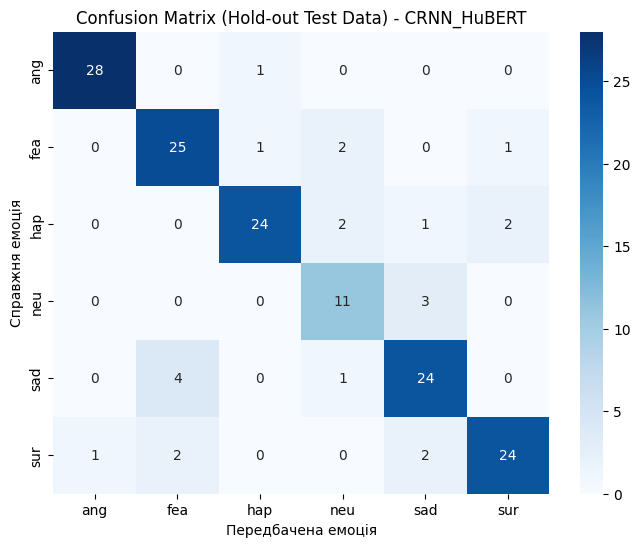

### 2. ROC-AUC

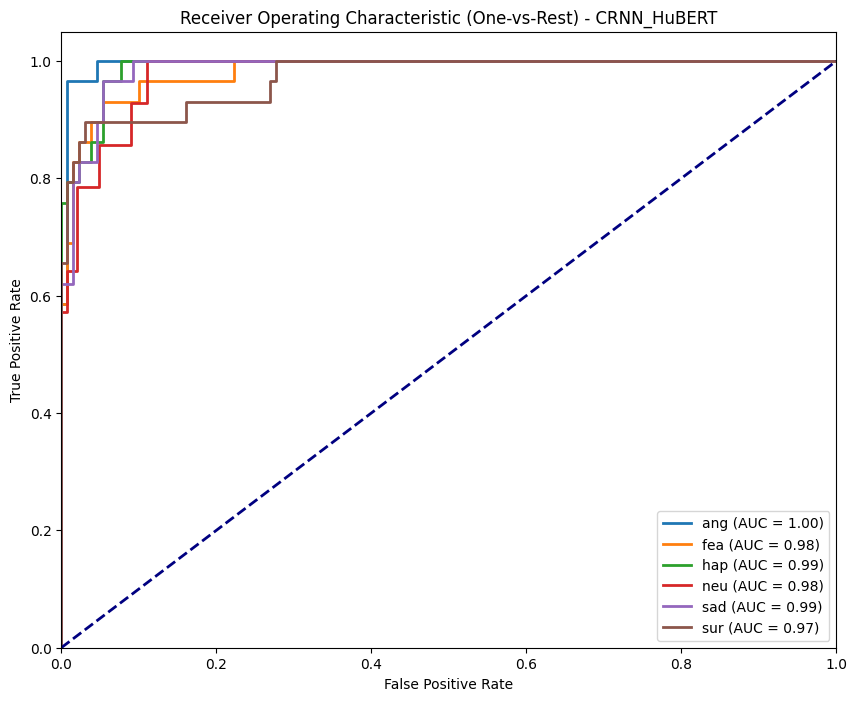

### 3. Криві навчання

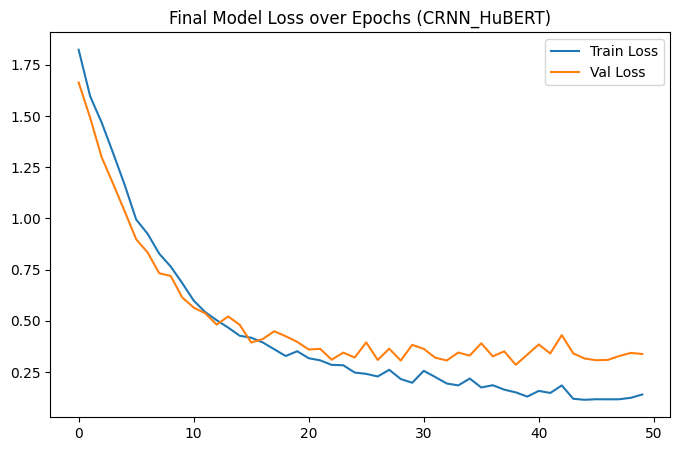

---

## Результати для: CRNN_Wav2Vec2

### 1. Матриця плутанини

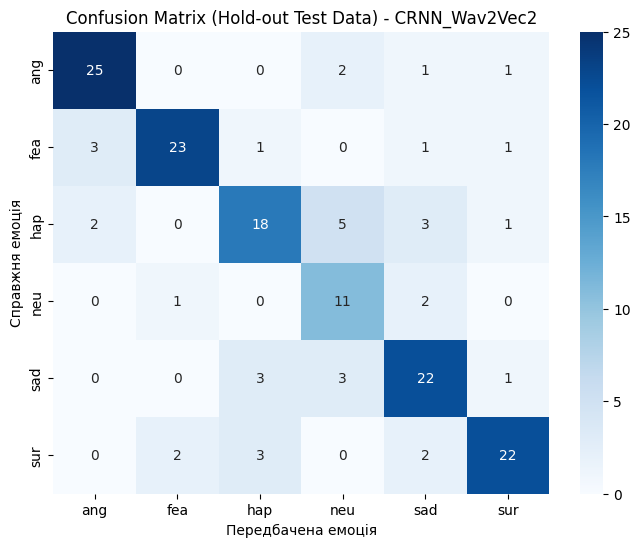

### 2. ROC-AUC

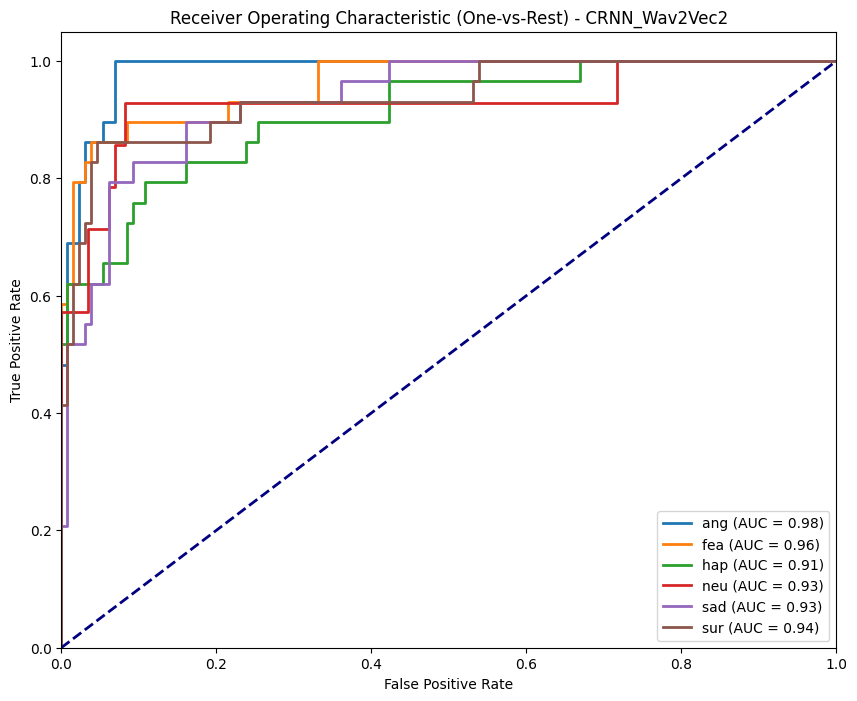

### 3. Криві навчання

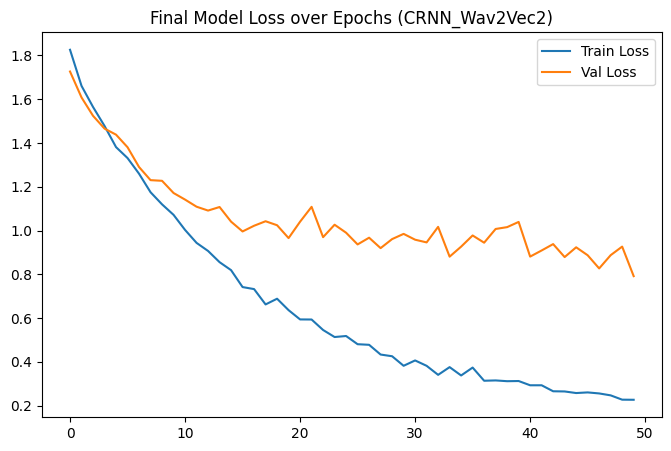

---

## Результати для: CRNN_VGGish

### 1. Матриця плутанини

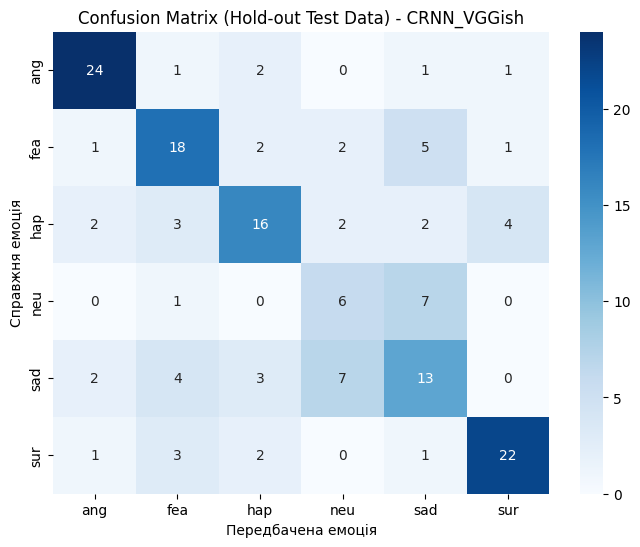

### 2. ROC-AUC

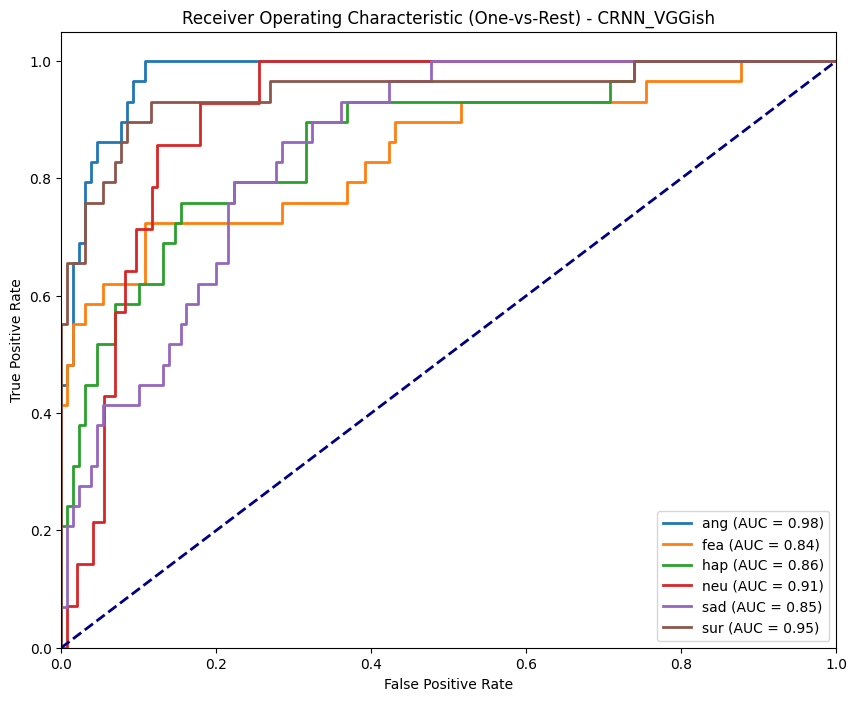

### 3. Криві навчання

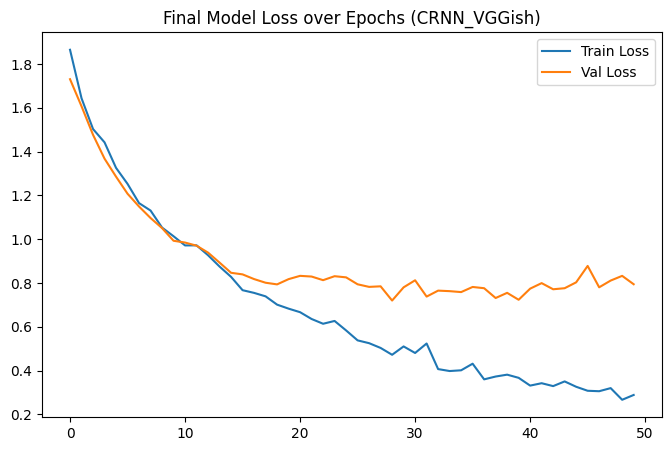

---

In [22]:
from IPython.display import Image, display, Markdown
import os

run_names = ["CRNN_HuBERT", "CRNN_Wav2Vec2", "CRNN_VGGish"]

for run in run_names:
    if os.path.exists(f"temp/{run}_confusion_matrix.png"):
        display(Markdown(f"## Результати для: {run}"))
        
        display(Markdown("### 1. Матриця плутанини"))
        display(Image(filename=f"temp/{run}_confusion_matrix.png"))
        
        display(Markdown("### 2. ROC-AUC"))
        display(Image(filename=f"temp/{run}_roc_curve.png"))
        
        display(Markdown("### 3. Криві навчання"))
        display(Image(filename=f"temp/{run}_learning_curves.png"))
        display(Markdown("---"))